# Module 1: Download and Map GEOS-FP Aerosol Data

**Technical Training on GEOS Data for Air Quality Monitoring in Lao PDR**  
Bangkok, 7 September 2026

This lab follows one reproducible acquisition path:

1. Open NASA GEOS-FP aerosol data through OPeNDAP.
2. Inspect PM2.5 and aerosol-speciation variables and map one global field.
3. Define a bounding box, dates, and variables; download only that subset.
4. Plot the regional GEOS subset with Cartopy.
5. Query OpenAQ reference-monitor PM2.5 for the same box and dates and overlay stations as circles.

The lab uses only the GEOS-FP `tavg3_2d_aer_Nx` aerosol collection.


## 0. Colab setup

Run this cell once in a new Google Colab runtime. It retrieves the course
repository and installs the shared environment. The cell is idempotent.


In [ ]:
# --- What this cell does ---
# Clones the participant repository in a fresh Colab runtime.
# Locates the same project root when the notebook runs from a local clone.
# Installs the shared scientific Python environment used by this module.
# --- End annotation ---
from pathlib import Path
import subprocess
import sys

REPO_NAME = "GEOS_Air_Quality_Training_Bangkok_2026"
REPO_URL = "https://github.com/alqamahsayeed12/GEOS_Air_Quality_Training_Bangkok_2026.git"
# Use one setup path in Colab and another when instructors test a local clone.
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    TRAINING_ROOT = Path("/content") / REPO_NAME
    if not (TRAINING_ROOT / ".git").exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", REPO_URL, str(TRAINING_ROOT)],
            check=True,
        )
    else:
        subprocess.run(
            ["git", "-C", str(TRAINING_ROOT), "pull", "--ff-only"],
            check=True,
        )
else:
    candidates = [Path.cwd(), Path.cwd().parent]
    TRAINING_ROOT = next(
        (path.resolve() for path in candidates if (path / "requirements-colab.txt").exists()),
        None,
    )
    if TRAINING_ROOT is None:
        raise FileNotFoundError("Run this notebook from the cloned repository.")

requirements_path = TRAINING_ROOT / "requirements-colab.txt"
print("Python:", sys.version.split()[0])
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "-r", str(requirements_path)],
    check=True,
)
print("Training root:", TRAINING_ROOT)


In [2]:
# --- What this cell does ---
# Imports mapping, array, table, HTTP, and NetCDF libraries.
# Creates one output directory that works in Colab and on a local computer.
# --- End annotation ---
from getpass import getpass
from pathlib import Path
import sys

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import xarray as xr

OUTPUT_DIR = TRAINING_ROOT / "outputs" / "module1"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Output folder:", OUTPUT_DIR)


Output folder: {TRAINING_ROOT}/outputs/module1


## 1. Acquire the GEOS-FP aerosol collection

The `.latest` endpoint follows the current operational forecast cycle. The cell
tries the live NASA service first and validates it with a small data read. If the
service is unavailable, it opens the committed Southeast Asia recovery snapshot
and prints that choice. Set `PREFER_LIVE_GEOS = False` to demonstrate the
offline path deliberately.


In [3]:
# --- What this cell does ---
# Opens the live GEOS-FP aerosol forecast and verifies a real value can be read.
# Falls back to a timestamp-preserving regional snapshot if the service fails.
# Normalizes variable names and units and reports the active source explicitly.
# --- End annotation ---
OPENDAP_URL = (
    "https://opendap.nccs.nasa.gov/dods/GEOS-5/fp/0.25_deg/"
    "fcast/tavg3_2d_aer_Nx.latest"
)
MODULE1_DATA = TRAINING_ROOT / "data" / "module1"
REGIONAL_RECOVERY_FILE = MODULE1_DATA / "geos_fp_regional_aerosol_snapshot.nc4"
GLOBAL_RECOVERY_FILE = MODULE1_DATA / "geos_fp_global_pm25_snapshot.nc4"
# Set this to False only when demonstrating the bundled recovery data offline.
PREFER_LIVE_GEOS = True

# Request only aerosol and PM2.5 fields needed later, which keeps the remote subset focused.
requested_aerosol_variables = [
    "PM25", "DUSMASS25", "SSSMASS25", "BCSMASS", "OCSMASS",
    "BRSMASS", "SO4SMASS", "NISMASS25", "NH4SMASS", "TOTEXTTAU",
]


def normalize_geos_dataset(dataset):
    """Normalize GrADS names, decode its historical time units, and add units."""
    time_units = dataset.time.attrs.get("units", "")
    if time_units.startswith("days since 1-1-1"):
        dataset.time.attrs["units"] = time_units.replace(
            "days since 1-1-1", "days since 0001-01-01", 1
        )
    dataset = xr.decode_cf(dataset)
    dataset = dataset.rename({name: name.upper() for name in dataset.data_vars})
    concentration_variables = {
        "PM25", "DUSMASS25", "SSSMASS25", "BCSMASS", "OCSMASS",
        "BRSMASS", "SO4SMASS", "NISMASS25", "NH4SMASS",
    }
    for name in concentration_variables.intersection(dataset.data_vars):
        dataset[name].attrs["units"] = "kg m-3"
    if "TOTEXTTAU" in dataset:
        dataset["TOTEXTTAU"].attrs["units"] = "1"
    return dataset


GEOS_LIVE_AVAILABLE = False
geos_live_error = None
try:
    if not PREFER_LIVE_GEOS:
        raise RuntimeError("Live GEOS access disabled by participant")
    # Open the OPeNDAP dataset lazily; values are transferred only when selected or loaded.
    candidate = xr.open_dataset(OPENDAP_URL, engine="netcdf4", decode_times=False)
    candidate = normalize_geos_dataset(candidate)
    # OPeNDAP access is lazy. Read one actual value so a failed server is caught here.
    _ = candidate["PM25"].isel(time=0, lat=0, lon=0).load().item()
    ds = candidate
    GEOS_LIVE_AVAILABLE = True
    GEOS_SOURCE_MODE = "live NASA GEOS-FP OPeNDAP"
except Exception as error:
    geos_live_error = f"{type(error).__name__}: {error}"
    ds = normalize_geos_dataset(xr.open_dataset(REGIONAL_RECOVERY_FILE, decode_times=False))
    GEOS_SOURCE_MODE = "bundled GEOS-FP regional recovery snapshot"

available_aerosol_variables = [
    variable for variable in requested_aerosol_variables if variable in ds.data_vars
]
missing_aerosol_variables = [
    variable for variable in requested_aerosol_variables if variable not in ds.data_vars
]
available_times_utc = pd.to_datetime(ds.time.values, utc=True)

print("GEOS source:", GEOS_SOURCE_MODE)
if geos_live_error:
    print("Live-service reason:", geos_live_error)
print(ds)
print("Available training variables:", available_aerosol_variables)
print("Missing from this source:", missing_aerosol_variables or "none")
print("Available valid times:", available_times_utc[0], "to", available_times_utc[-1])


<xarray.Dataset> Size: 3GB
Dimensions:      (time: 11, lat: 721, lon: 1152)
Coordinates:
  * time         (time) datetime64[ns] 88B 2026-08-26T04:30:00 ... 2026-08-27...
  * lat          (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon          (lon) float64 9kB -180.0 -179.7 -179.4 ... 179.1 179.4 179.7
Data variables: (12/78)
    NISMASS25    (time, lat, lon) float32 37MB ...
    DMSSMASS     (time, lat, lon) float32 37MB ...
    SSCMASS25    (time, lat, lon) float32 37MB ...
    DUFLUXV      (time, lat, lon) float32 37MB ...
    BRANGSTR     (time, lat, lon) float32 37MB ...
    OCSCATAU     (time, lat, lon) float32 37MB ...
    ...           ...
    SSEXTT25     (time, lat, lon) float32 37MB ...
    SUEXTTAU     (time, lat, lon) float32 37MB ...
    BRFLUXV      (time, lat, lon) float32 37MB ...
    BCSMASS      (time, lat, lon) float32 37MB ...
    OCFLUXV      (time, lat, lon) float32 37MB ...
    SSCMASS      (time, lat, lon) float32 37MB ...
Attributes:
 

## 2. Plot one GEOS field globally

Only one time and one variable are requested from the remote dataset. Concentration variables with native `kg m-3` units are converted to `µg m-3` for display.


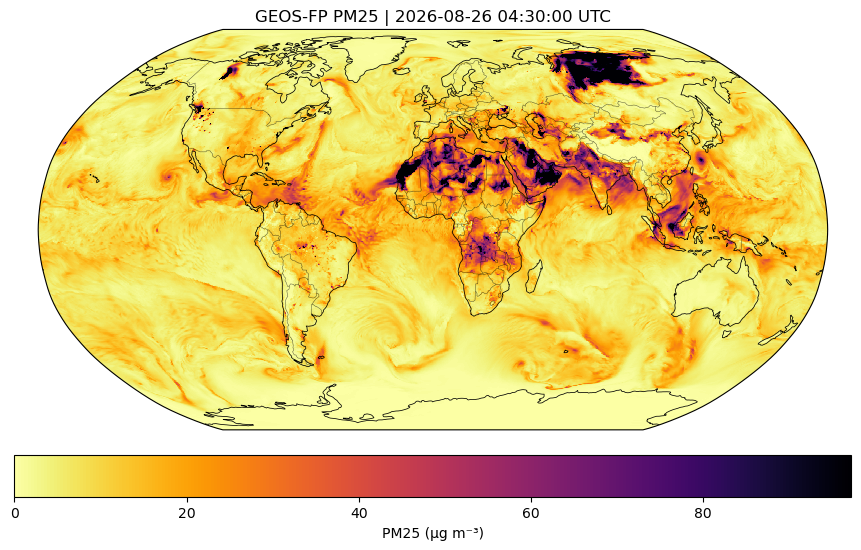

In [4]:
# --- What this cell does ---
# Loads one global GEOS PM2.5 field from the live service when available.
# Uses the bundled real global snapshot if the live service failed.
# Converts concentration units and draws a global Cartopy map.
# --- End annotation ---
GLOBAL_VARIABLE = "PM25"
GLOBAL_TIME_INDEX = 0

if GEOS_LIVE_AVAILABLE:
    global_field = ds[GLOBAL_VARIABLE].isel(time=GLOBAL_TIME_INDEX).load()
    global_source_label = GEOS_SOURCE_MODE
else:
    with xr.open_dataset(GLOBAL_RECOVERY_FILE) as global_recovery:
        global_field = global_recovery[GLOBAL_VARIABLE].isel(time=0).load()
    global_source_label = "bundled real GEOS-FP global recovery snapshot"

global_units = global_field.attrs.get("units", "")
# Convert mass concentration from kg m-3 to µg m-3 before interpreting or plotting it.
if "kg" in global_units and "m-3" in global_units:
    global_field = global_field * 1e9
    global_units = "µg m⁻³"

finite = np.asarray(global_field.values)[np.isfinite(global_field.values)]
# Use a robust percentile so a few extreme cells do not flatten the map colors.
color_max = float(np.nanpercentile(finite, 99))

fig = plt.figure(figsize=(15, 6.5))
ax = plt.axes(projection=ccrs.Robinson())
mesh = ax.pcolormesh(
    global_field.lon, global_field.lat, global_field,
    transform=ccrs.PlateCarree(), cmap="inferno_r",
    vmin=0, vmax=color_max, shading="auto",
)
ax.set_global()
ax.add_feature(cfeature.LAND, facecolor="#eeeeea", zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.55)
ax.add_feature(cfeature.BORDERS, linewidth=0.35, alpha=0.65)
ax.set_title(
    f"GEOS-FP {GLOBAL_VARIABLE} | {pd.Timestamp(global_field.time.values)} UTC\n"
    f"Source: {global_source_label}"
)
plt.colorbar(
    mesh, ax=ax, orientation="horizontal", pad=0.05, shrink=0.72,
    label=f"{GLOBAL_VARIABLE} ({global_units})",
)
plt.show()


## 3. Define the bounding box, dates, and aerosol variables

Edit this single configuration cell. Bounding-box order is **west, south, east, north** in WGS84 longitude/latitude. Dates must fall inside the valid-time range printed above.


In [5]:
# --- What this cell does ---
# Collects the participant-controlled bounding box, UTC interval, and variables.
# Defaults to the first 24 hours, or all available times in a shorter snapshot.
# --- End annotation ---
# Bounding boxes follow west, south, east, north in geographic coordinates.
BBOX = [95.0, 5.0, 110.0, 25.0]  # west, south, east, north
DATE_FROM = available_times_utc[0].isoformat()
DATE_TO = available_times_utc[min(7, ds.sizes["time"] - 1)].isoformat()

VARIABLES = [
    variable for variable in [
        "PM25", "DUSMASS25", "SSSMASS25", "BCSMASS", "OCSMASS",
        "BRSMASS", "SO4SMASS", "NISMASS25", "NH4SMASS",
    ]
    if variable in ds.data_vars
]

print("BBOX:", BBOX)
print("UTC interval:", DATE_FROM, "to", DATE_TO)
print("Requested variables:", VARIABLES)
print("GEOS source:", GEOS_SOURCE_MODE)


BBOX: [95.0, 5.0, 110.0, 25.0]
UTC interval: 2026-08-26T04:30:00+00:00 to 2026-08-27T01:30:00+00:00
Requested variables: ['PM25', 'DUSMASS25', 'SSSMASS25', 'BCSMASS', 'OCSMASS', 'BRSMASS', 'SO4SMASS', 'NISMASS25', 'NH4SMASS']


In [6]:
# --- What this cell does ---
# Validates the spatial, temporal, and variable selections before downloading data.
# Subsets the remote collection through OPeNDAP and saves the result as NetCDF.
# --- End annotation ---
west, south, east, north = BBOX

if not (-180 <= west < east <= 180 and -90 <= south < north <= 90):
    raise ValueError("BBOX must be [west, south, east, north] in WGS84 and must not cross the dateline.")

unknown = sorted(set(VARIABLES) - set(ds.data_vars))
if unknown:
    raise KeyError(f"These variables are unavailable in the active GEOS source: {unknown}")

# Parse participant dates explicitly, then normalize both endpoints to UTC.
start = pd.Timestamp(DATE_FROM)
end = pd.Timestamp(DATE_TO)
if start.tzinfo is None:
    start = start.tz_localize("UTC")
else:
    start = start.tz_convert("UTC")
if end.tzinfo is None:
    end = end.tz_localize("UTC")
else:
    end = end.tz_convert("UTC")

available_start = available_times_utc[0]
available_end = available_times_utc[-1]
if start < available_start or end > available_end or start > end:
    raise ValueError(
        f"Choose dates between {available_start.isoformat()} and {available_end.isoformat()}"
    )

# OPeNDAP transfers only the requested variables, time range, and grid cells.
start_for_xarray = start.tz_localize(None)
end_for_xarray = end.tz_localize(None)
regional = (
    ds[VARIABLES]
    .sortby("lat")
    .sortby("lon")
    # Perform the time and bounding-box selection on the server through OPeNDAP.
    .sel(time=slice(start_for_xarray, end_for_xarray), lat=slice(south, north), lon=slice(west, east))
    .load()
)

regional.attrs.update({
    "source_mode": GEOS_SOURCE_MODE,
    "source_opendap_url": OPENDAP_URL if GEOS_LIVE_AVAILABLE else "",
    "recovery_file": "" if GEOS_LIVE_AVAILABLE else REGIONAL_RECOVERY_FILE.name,
    "requested_bbox_wsen": ",".join(map(str, BBOX)),
    "requested_utc_start": start.isoformat(),
    "requested_utc_end": end.isoformat(),
})

geos_subset_file = OUTPUT_DIR / "geos_fp_aerosol_bbox.nc4"
# Persist the exact analysis subset so later cells no longer depend on the live service.
regional.to_netcdf(geos_subset_file)
print(regional)
print(f"\nSaved {geos_subset_file} ({geos_subset_file.stat().st_size / 1024**2:.2f} MiB)")


<xarray.Dataset> Size: 1MB
Dimensions:    (time: 8, lat: 81, lon: 49)
Coordinates:
  * time       (time) datetime64[ns] 64B 2026-08-26T04:30:00 ... 2026-08-27T0...
  * lat        (lat) float64 648B 5.0 5.25 5.5 5.75 ... 24.25 24.5 24.75 25.0
  * lon        (lon) float64 392B 95.0 95.31 95.62 95.94 ... 109.4 109.7 110.0
Data variables:
    PM25       (time, lat, lon) float32 127kB 8.785e-09 7.606e-09 ... 2.394e-08
    DUSMASS25  (time, lat, lon) float32 127kB 9.925e-14 8.464e-13 ... 1.819e-10
    SSSMASS25  (time, lat, lon) float32 127kB 8.527e-09 6.228e-09 ... 3.142e-10
    BCSMASS    (time, lat, lon) float32 127kB 8.557e-12 6.56e-11 ... 9.932e-10
    OCSMASS    (time, lat, lon) float32 127kB 4.446e-11 9.713e-10 ... 9.546e-09
    BRSMASS    (time, lat, lon) float32 127kB 1.056e-11 6.003e-11 ... 1.637e-10
    SO4SMASS   (time, lat, lon) float32 127kB 1.368e-10 2.014e-10 ... 6.367e-09
    NISMASS25  (time, lat, lon) float32 127kB 1.512e-13 1.83e-13 ... 3.107e-09
    NH4SMASS   (time, lat

## 4. Plot the downloaded regional subset

Select any downloaded aerosol variable. The map extent is exactly the participant-defined bounding box.


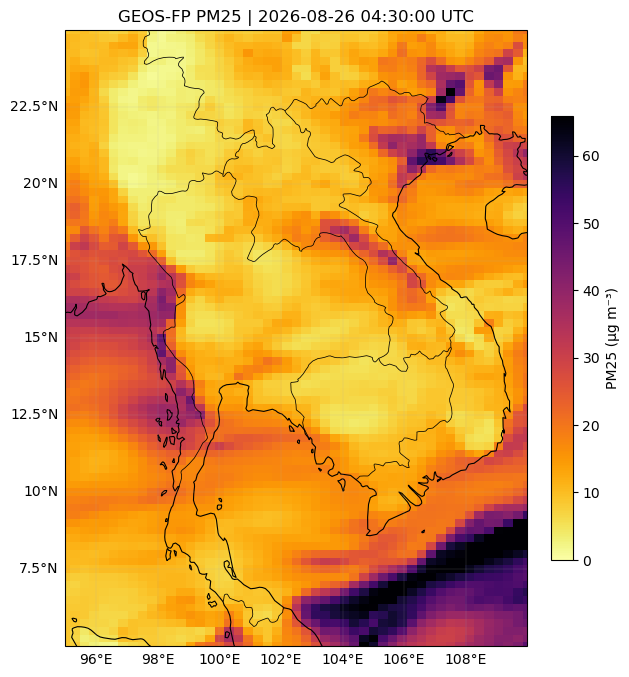

In [7]:
# --- What this cell does ---
# Selects one variable and timestamp from the downloaded regional subset.
# Converts units and plots the participant-defined domain with Cartopy.
# --- End annotation ---
PLOT_VARIABLE = "PM25"
PLOT_TIME_INDEX = 0

# Select one valid time while retaining latitude and longitude dimensions.
regional_field = regional[PLOT_VARIABLE].isel(time=PLOT_TIME_INDEX)
regional_units = regional_field.attrs.get("units", "")
if "kg" in regional_units and "m-3" in regional_units:
    regional_field = regional_field * 1e9
    regional_units = "µg m⁻³"

values = np.asarray(regional_field.values)
regional_max = float(np.nanpercentile(values[np.isfinite(values)], 99))

fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
mesh = ax.pcolormesh(
    regional_field.lon,
    regional_field.lat,
    regional_field,
    transform=ccrs.PlateCarree(),
    cmap="inferno_r",
    vmin=0,
    vmax=regional_max,
    shading="auto",
)
ax.set_extent([west, east, south, north], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="#f2f2ee", zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.55)
gridlines = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4)
gridlines.top_labels = False
gridlines.right_labels = False
ax.set_title(f"GEOS-FP {PLOT_VARIABLE} | {pd.Timestamp(regional_field.time.values)} UTC")
plt.colorbar(mesh, ax=ax, shrink=0.72, pad=0.03,
             label=f"{PLOT_VARIABLE} ({regional_units})")
plt.show()


## 5. Why the PM2.5 formula depends on the GEOS generation

NASA documents three aerosol formulations. To make the change visible, we reconstruct **dry geometric PM2.5** from the current GOCART-2G fields while setting all relative-humidity growth factors to 1, then compare each reconstruction against the embedded current `PM25` field.

| Formulation | Dry reconstruction used in this comparison | Main limitation on current data |
|---|---|---|
| MERRA-2 | dust + sea salt + BC + OC + 1.3756 × sulfate | No nitrate, ammonium, or brown carbon; legacy sulfate conversion |
| GEOS 5.16+ / GEOS-IT | dust + sea salt + BC + OC + sulfate + nitrate + ammonium | Predates separate brown-carbon diagnostics |
| GOCART-2G / GEOS-FP 5.43+ | GEOS 5.16+ terms + brown carbon | Matches the definition of embedded dry `PM25` |

The embedded field assumes a geometric diameter and 0% relative humidity. It is not automatically equivalent to regulatory, aerodynamic, or ambient-humidity PM2.5 observations.

NASA references:

- [GEOS-FP GOCART-2G implementation and PM2.5 guidance](https://gmao.gsfc.nasa.gov/media/publications/zbly36ziNFDQeVqPhUoFbmYmvh/fpaerosoldocumentation_o9h168lymkj3xde5u4t27n0iv.pdf)
- [Supplemental documentation for GEOS aerosol products](https://gmao.gsfc.nasa.gov/pubs/docs/Collow1489.pdf)


In [8]:
# --- What this cell does ---
# Reconstructs dry PM2.5 using three GEOS-generation aerosol formulations.
# Converts every reconstruction and the embedded GEOS PM25 field to µg/m³.
# --- End annotation ---
# Dry reconstructions: all relative-humidity growth factors are set to 1.
# MERRA-2 combines dry aerosol components and scales sulfate to represent associated ammonium.
merra2_pm25 = (
    regional["DUSMASS25"]
    + regional["SSSMASS25"]
    + regional["BCSMASS"]
    + regional["OCSMASS"]
    + 1.3756 * regional["SO4SMASS"]
)

# This reconstruction represents the earlier GEOS-FP aerosol formulation.
geos516_pm25 = (
    regional["DUSMASS25"]
    + regional["SSSMASS25"]
    + regional["BCSMASS"]
    + regional["OCSMASS"]
    + regional["SO4SMASS"]
    + regional["NISMASS25"]
    + regional["NH4SMASS"]
)

# The current formulation adds brown carbon to the nitrate- and ammonium-aware reconstruction.
gocart2g_pm25 = geos516_pm25 + regional["BRSMASS"]

embedded_pm25_ugm3 = regional["PM25"] * 1e9
reconstructed_pm25_ugm3 = {
    "MERRA-2 formulation": merra2_pm25 * 1e9,
    "GEOS 5.16+ / GEOS-IT": geos516_pm25 * 1e9,
    "GOCART-2G / GEOS-FP 5.43+": gocart2g_pm25 * 1e9,
}

print("Reference: embedded GEOS PM25 (dry geometric PM2.5 at 0% RH)")
for label, field in reconstructed_pm25_ugm3.items():
    print(f"{label:30s} mean = {float(field.mean()):7.3f} µg m⁻³")


Reference: embedded GEOS PM25 (dry geometric PM2.5 at 0% RH)
MERRA-2 formulation            mean =  16.508 µg m⁻³
GEOS 5.16+ / GEOS-IT           mean =  16.642 µg m⁻³
GOCART-2G / GEOS-FP 5.43+      mean =  18.496 µg m⁻³


In [9]:
# --- What this cell does ---
# Defines common comparison metrics: N, IOA, correlation, slope, RMSE, and mean bias.
# Applies the same metrics to each reconstructed PM2.5 formulation.
# --- End annotation ---
def comparison_metrics(reference, estimate):
    reference = np.asarray(reference, dtype=float).ravel()
    estimate = np.asarray(estimate, dtype=float).ravel()
    # Use identical finite pairs for every metric so sample sizes remain comparable.
    valid = np.isfinite(reference) & np.isfinite(estimate)
    reference = reference[valid]
    estimate = estimate[valid]

    # Willmott's original index of agreement uses squared error and a potential-error denominator.
    reference_mean = reference.mean()
    # Willmott IOA compares squared error with the potential error around the observed mean.
    denominator = np.sum(
        (np.abs(estimate - reference_mean) + np.abs(reference - reference_mean)) ** 2
    )
    ioa = 1.0 - np.sum((estimate - reference) ** 2) / denominator if denominator else np.nan
    correlation = np.corrcoef(reference, estimate)[0, 1] if reference.size > 1 else np.nan
    slope = np.polyfit(reference, estimate, 1)[0] if reference.size > 1 else np.nan
    rmse = np.sqrt(np.mean((estimate - reference) ** 2))
    mean_bias = np.mean(estimate - reference)

    return {
        "N": reference.size,
        "IOA": ioa,
        "r": correlation,
        "slope": slope,
        "RMSE": rmse,
        "mean_bias": mean_bias,
    }


metric_rows = []
for label, field in reconstructed_pm25_ugm3.items():
    values = comparison_metrics(embedded_pm25_ugm3.values, field.values)
    metric_rows.append({"formulation": label, **values})

metrics_table = pd.DataFrame(metric_rows)
metrics_table


,formulation,N,IOA,r,slope,RMSE,mean_bias
0,MERRA-2 formulation,31752,0.950517,0.947220,0.749984,4.585169,-1.987960
1,GEOS 5.16+ / GEOS-IT,31752,0.947911,0.936924,0.752619,4.719079,-1.853896
2,GOCART-2G / GEOS-FP 5.43+,31752,1.000000,1.000000,0.999995,0.010177,0.000051


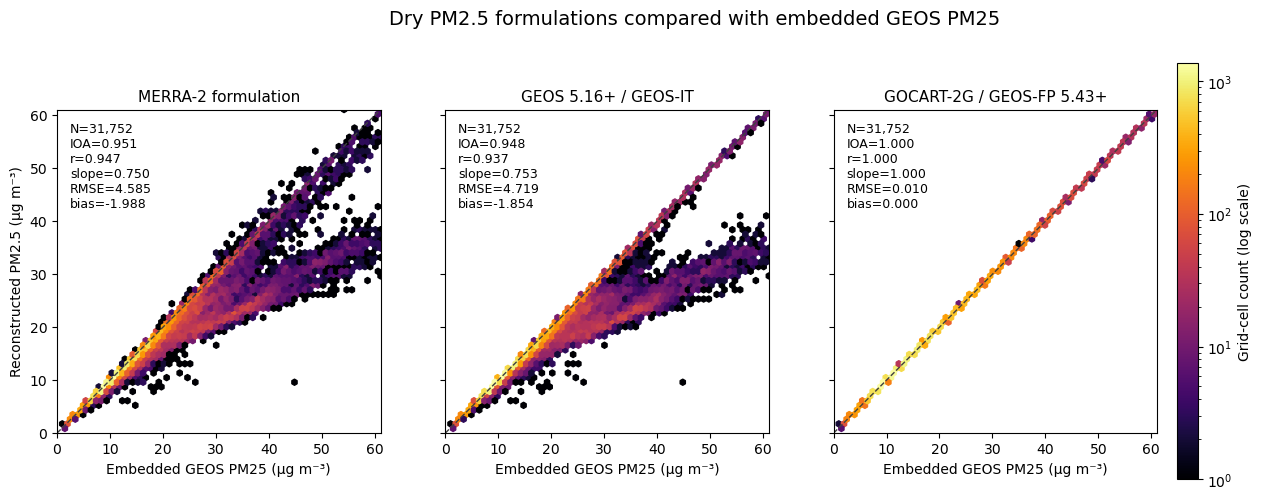

In [10]:
# --- What this cell does ---
# Compares each reconstructed PM2.5 field with embedded GEOS PM25.
# Uses three equal-axis density panels and annotates identical performance metrics.
# --- End annotation ---
reference_values = embedded_pm25_ugm3.values.ravel()
all_values = [reference_values]
all_values.extend(field.values.ravel() for field in reconstructed_pm25_ugm3.values())
finite_values = np.concatenate([values[np.isfinite(values)] for values in all_values])
# Apply one robust axis limit to all panels for a fair visual comparison.
axis_max = max(10.0, float(np.nanpercentile(finite_values, 99.5)))

fig, axes = plt.subplots(1, 3, figsize=(17, 5.4), sharex=True, sharey=True)

for ax, (label, field), metrics in zip(
    axes,
    reconstructed_pm25_ugm3.items(),
    metric_rows,
):
    estimate_values = field.values.ravel()
    valid = np.isfinite(reference_values) & np.isfinite(estimate_values)
    hexbin = ax.hexbin(
        reference_values[valid],
        estimate_values[valid],
        gridsize=62,
        extent=(0, axis_max, 0, axis_max),
        mincnt=1,
        bins="log",
        cmap="inferno",
    )
    ax.plot([0, axis_max], [0, axis_max], "--", color="0.25", linewidth=1)
    ax.set_xlim(0, axis_max)
    ax.set_ylim(0, axis_max)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("Embedded GEOS PM25 (µg m⁻³)")
    ax.text(
        0.04,
        0.96,
        f"N={metrics['N']:,}\n"
        f"IOA={metrics['IOA']:.3f}\n"
        f"r={metrics['r']:.3f}\n"
        f"slope={metrics['slope']:.3f}\n"
        f"RMSE={metrics['RMSE']:.3f}\n"
        f"bias={metrics['mean_bias']:.3f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=9,
        bbox={"facecolor": "white", "alpha": 0.82, "edgecolor": "none"},
    )

axes[0].set_ylabel("Reconstructed PM2.5 (µg m⁻³)")
fig.colorbar(hexbin, ax=axes, orientation="vertical", pad=0.015,
             label="Grid-cell count (log scale)")
fig.suptitle("Dry PM2.5 formulations compared with embedded GEOS PM25", fontsize=14)
plt.show()


### Interpretation

- **MERRA-2** should depart most because it lacks nitrate, ammonium, and brown carbon and applies a legacy sulfate conversion.
- **GEOS 5.16+ / GEOS-IT** should improve because nitrate and ammonium are explicit, but it still omits brown carbon.
- **GOCART-2G** should closely reproduce embedded `PM25`; remaining tiny differences should be numerical precision rather than a distinct physical formulation.
- Agreement with embedded `PM25` verifies reconstruction logic. It does **not** establish agreement with ground monitors.


## 6. Download matching reference-monitor PM2.5 from OpenAQ

OpenAQ API v3 requires a free personal API key for the live exercise. Register
through [OpenAQ Explorer](https://explore.openaq.org/register), then copy the key
from [Account Settings](https://explore.openaq.org/account). The hidden prompt
does not save the key in the notebook.

Press **Enter without a key**, set `PREFER_LIVE_OPENAQ = False`, or continue after
a network/API failure to use the committed OpenAQ recovery tables. Their original
timestamps are retained. If those timestamps differ from the active GEOS field,
the final map is explicitly a spatial teaching overlay, not temporal validation.

Never put a key in a code cell, notebook output, screenshot, issue, or commit.


In [2]:
# --- What this cell does ---
# Requests an OpenAQ API key through a hidden prompt and queries live locations.
# Selects the bundled recovery path if the key is blank or the request fails.
# --- End annotation ---
PREFER_LIVE_OPENAQ = True
OPENAQ_BASE = "https://api.openaq.org/v3"
# Prompt securely so the API key is not printed or stored inside the notebook.
OPENAQ_API_KEY = getpass(
    "Paste your OpenAQ API key, or press Enter for the bundled recovery data: "
).strip()
headers = {"X-API-Key": OPENAQ_API_KEY} if OPENAQ_API_KEY else {}
bbox_text = ",".join(map(str, BBOX))

locations = []
openaq_live_error = None
OPENAQ_LIVE_AVAILABLE = False
if PREFER_LIVE_OPENAQ and OPENAQ_API_KEY:
    try:
        location_response = requests.get(
            f"{OPENAQ_BASE}/locations",
            headers=headers,
            params={
                "bbox": bbox_text,
                "parameters_id": 2,
                "monitor": "true",
                "mobile": "false",
                "limit": 1000,
                "page": 1,
            },
            timeout=60,
        )
        location_response.raise_for_status()
        locations = location_response.json().get("results", [])
        if not locations:
            raise RuntimeError("The live query returned no matching locations")
        OPENAQ_LIVE_AVAILABLE = True
    except Exception as error:
        openaq_live_error = f"{type(error).__name__}: {error}"
elif not OPENAQ_API_KEY:
    openaq_live_error = "No API key entered"
else:
    openaq_live_error = "Live OpenAQ access disabled by participant"

OPENAQ_SOURCE_MODE = (
    "live OpenAQ API v3" if OPENAQ_LIVE_AVAILABLE
    else "bundled OpenAQ recovery snapshot"
)
print("OpenAQ source:", OPENAQ_SOURCE_MODE)
if openaq_live_error:
    print("Live-service reason:", openaq_live_error)
print("Reference-monitor locations returned:", len(locations))


Reference-monitor locations returned: 388


In [3]:
# --- What this cell does ---
# Downloads live hourly OpenAQ PM2.5 with caching, pagination, and retries.
# Loads schema-compatible recovery tables if the live path yields no observations.
# Applies concentration QA/QC and records the source and original time coverage.
# --- End annotation ---
import json
import time

OPENAQ_CACHE_DIR = OUTPUT_DIR / "openaq_hour_cache"
OPENAQ_CACHE_DIR.mkdir(parents=True, exist_ok=True)


def get_openaq_sensor_page(sensor_id, page):
    """Download one sensor page with caching and bounded retries."""
    # Cache each API page to avoid repeating requests during instruction or troubleshooting.
    cache_file = OPENAQ_CACHE_DIR / f"sensor_{sensor_id}_page_{page}.json"
    if cache_file.exists():
        return json.loads(cache_file.read_text(encoding="utf-8")), None
    for attempt in range(1, 4):
        try:
            response = requests.get(
                f"{OPENAQ_BASE}/sensors/{sensor_id}/hours",
                headers=headers,
                params={
                    "datetime_from": start.isoformat(),
                    "datetime_to": end.isoformat(),
                    "limit": 1000,
                    "page": page,
                },
                timeout=60,
            )
            if response.status_code == 429:
                time.sleep(max(int(float(response.headers.get("X-Ratelimit-Reset", 5))), 1) + 1)
                continue
            if response.status_code >= 500:
                time.sleep(5 * attempt)
                continue
            response.raise_for_status()
            payload = response.json()
            cache_file.write_text(json.dumps(payload), encoding="utf-8")
            return payload, None
        except requests.RequestException as error:
            if attempt == 3:
                return None, f"{type(error).__name__}: {error}"
            time.sleep(5 * attempt)
    return None, "request attempts exhausted"


station_rows = []
measurement_rows = []
failed_requests = []
if OPENAQ_LIVE_AVAILABLE:
    for location in locations:
        coordinates = location.get("coordinates") or {}
        pm25_sensors = [
            sensor for sensor in location.get("sensors", [])
            if (sensor.get("parameter") or {}).get("name") == "pm25"
        ]
        for sensor in pm25_sensors:
            station_rows.append({
                "location_id": location.get("id"),
                "location_name": location.get("name"),
                "sensor_id": sensor.get("id"),
                "sensor_name": sensor.get("name"),
                "latitude": coordinates.get("latitude"),
                "longitude": coordinates.get("longitude"),
                "country": (location.get("country") or {}).get("code"),
                "provider": (location.get("provider") or {}).get("name"),
                "owner": (location.get("owner") or {}).get("name"),
                "instruments": "; ".join(
                    item.get("name", "") for item in location.get("instruments", [])
                ),
                "monitor": location.get("isMonitor", location.get("monitor", True)),
            })
            page = 1
            while True:
                payload, error_message = get_openaq_sensor_page(sensor["id"], page)
                if payload is None:
                    failed_requests.append({
                        "location_id": location.get("id"), "sensor_id": sensor.get("id"),
                        "page": page, "error": error_message,
                    })
                    break
                rows = payload.get("results", [])
                for item in rows:
                    period = item.get("period") or {}
                    datetime_to = period.get("datetimeTo") or item.get("datetime") or {}
                    measurement_rows.append({
                        "location_id": location.get("id"),
                        "location_name": location.get("name"),
                        "sensor_id": sensor.get("id"),
                        "datetime_utc": datetime_to.get("utc"),
                        "pm25_ug_m3": item.get("value"),
                        "latitude": coordinates.get("latitude"),
                        "longitude": coordinates.get("longitude"),
                        "provider": (location.get("provider") or {}).get("name"),
                        "owner": (location.get("owner") or {}).get("name"),
                    })
                found = int((payload.get("meta") or {}).get("found", len(rows)))
                if page * 1000 >= found or not rows:
                    break
                page += 1

stations = pd.DataFrame(station_rows)
observations = pd.DataFrame(measurement_rows)
failed = pd.DataFrame(failed_requests)

if observations.empty:
    stations = pd.read_csv(MODULE1_DATA / "openaq_reference_pm25_stations.csv")
    observations = pd.read_csv(MODULE1_DATA / "openaq_reference_pm25_hourly.csv")
    failed = pd.DataFrame(columns=["location_id", "sensor_id", "page", "error"])
    OPENAQ_SOURCE_MODE = "bundled OpenAQ recovery snapshot"

stations = stations.drop_duplicates(subset=["sensor_id"]).copy()
observations["datetime_utc"] = pd.to_datetime(observations["datetime_utc"], utc=True)
observations["pm25_ug_m3"] = pd.to_numeric(observations["pm25_ug_m3"], errors="coerce")
# Apply the declared concentration and bounding-box filters before station-model comparison.
observations = observations[
    observations["pm25_ug_m3"].between(0, 1000, inclusive="both")
    & observations["longitude"].between(west, east)
    & observations["latitude"].between(south, north)
].copy()

observation_start = observations["datetime_utc"].min()
observation_end = observations["datetime_utc"].max()
observation_period_text = f"{observation_start} to {observation_end}"

stations_file = OUTPUT_DIR / "openaq_reference_pm25_stations.csv"
observations_file = OUTPUT_DIR / "openaq_reference_pm25_hourly.csv"
failed_file = OUTPUT_DIR / "openaq_failed_sensor_requests.csv"
stations.to_csv(stations_file, index=False)
observations.to_csv(observations_file, index=False)
failed.to_csv(failed_file, index=False)

print("OpenAQ source:", OPENAQ_SOURCE_MODE)
print("Observation time coverage:", observation_period_text)
print("Station-sensor records:", len(stations))
print("Valid hourly observations in BBOX:", len(observations))
print("Skipped live sensor-page requests:", len(failed))
if OPENAQ_SOURCE_MODE.startswith("bundled"):
    print("Offline overlay is spatial context only unless its timestamps match GEOS.")


OpenAQ rate limit reached; waiting 52 seconds...


Sensor 16312716: OpenAQ HTTP 500; retrying in 5 seconds...


Sensor 16312716: OpenAQ HTTP 500; retrying in 10 seconds...


OpenAQ rate limit reached; waiting 37 seconds...


OpenAQ rate limit reached; waiting 52 seconds...


...

OpenAQ rate limit reached; waiting 36 seconds...


OpenAQ rate limit reached; waiting 52 seconds...


OpenAQ rate limit reached; waiting 52 seconds...


OpenAQ rate limit reached; waiting 52 seconds...


Station-sensor records: 524
Valid hourly observations: 1926
Skipped sensor-page requests: 3
Saved: {TRAINING_ROOT}/outputs/module1/openaq_reference_pm25_stations.csv
Saved: {TRAINING_ROOT}/outputs/module1/openaq_reference_pm25_hourly.csv
Saved: {TRAINING_ROOT}/outputs/module1/openaq_failed_sensor_requests.csv


## 7. Overlay OpenAQ station PM2.5 on the GEOS map

Each circle is a reference-monitor location colored by its mean hourly PM2.5 over the selected interval. The GEOS background uses the first selected 3-hour timestamp. Shared units and a common color scale make the layers directly readable, but this is not yet a formal collocation or validation.


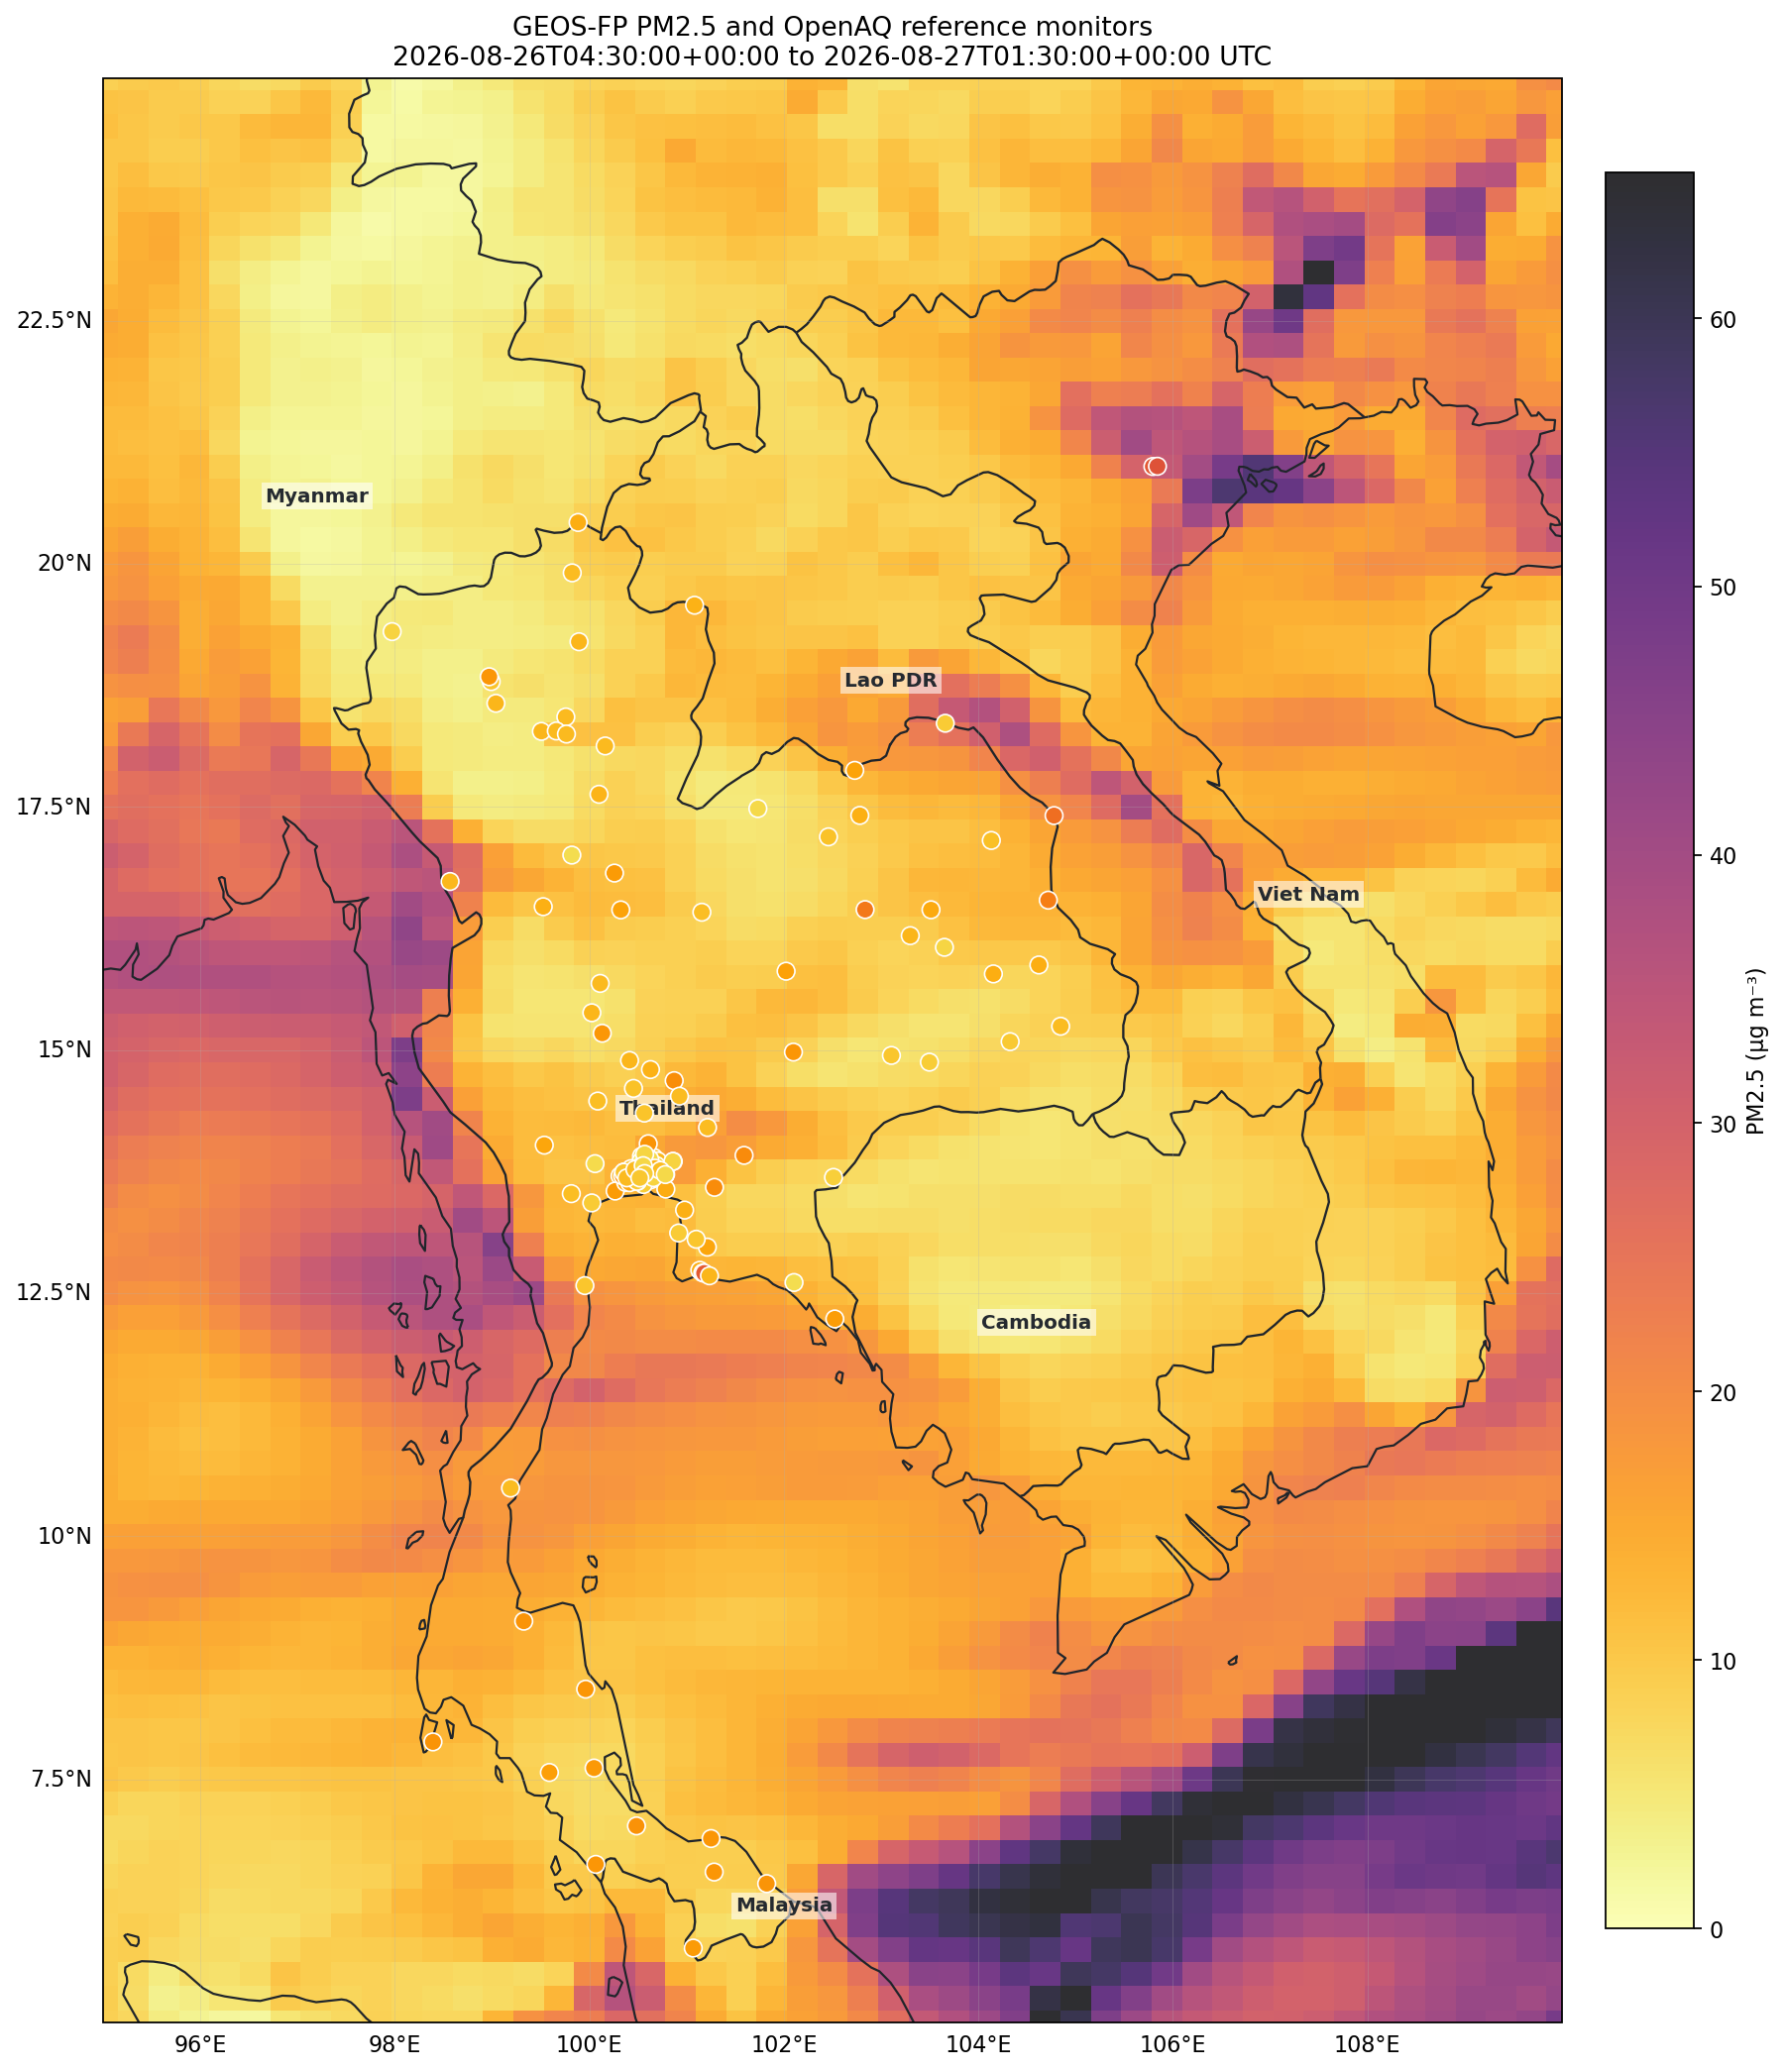

In [2]:
# --- What this cell does ---
# Averages hourly PM2.5 by OpenAQ station for the selected interval.
# Overlays station circles on GEOS PM2.5 using one shared concentration scale.
# --- End annotation ---
if observations.empty:
    raise RuntimeError("No OpenAQ observations are available to map for the selected interval.")

# Average repeated hourly records to one value per mapped station and interval.
station_means = (
    observations.groupby(["location_id", "location_name", "latitude", "longitude"], as_index=False)
    ["pm25_ug_m3"].mean()
)

geos_pm25 = regional["PM25"].isel(time=0)
geos_pm25_units = geos_pm25.attrs.get("units", "")
if "kg" in geos_pm25_units and "m-3" in geos_pm25_units:
    geos_pm25 = geos_pm25 * 1e9

# One robust upper limit makes GEOS cells and station circles visually comparable.
# Share one robust color limit between the gridded field and station circles.
combined_max = float(np.nanpercentile(
    np.concatenate([
        np.asarray(geos_pm25.values).ravel(),
        station_means["pm25_ug_m3"].to_numpy(),
    ]),
    99,
))

fig = plt.figure(figsize=(12, 14.5), dpi=160)
ax = plt.axes(projection=ccrs.PlateCarree())
mesh = ax.pcolormesh(
    geos_pm25.lon,
    geos_pm25.lat,
    geos_pm25,
    transform=ccrs.PlateCarree(),
    cmap="inferno_r",
    vmin=0,
    vmax=combined_max,
    shading="auto",
    alpha=0.82,
)
ax.scatter(
    station_means["longitude"],
    station_means["latitude"],
    c=station_means["pm25_ug_m3"],
    cmap="inferno_r",
    vmin=0,
    vmax=combined_max,
    s=64,
    edgecolor="white",
    linewidth=0.75,
    transform=ccrs.PlateCarree(),
    zorder=5,
)
ax.set_extent([west, east, south, north], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=1.0, edgecolor="#20252b")
ax.add_feature(cfeature.BORDERS, linewidth=1.05, edgecolor="#20252b")

country_labels = {
    "Myanmar": (97.2, 20.7),
    "Thailand": (100.8, 14.4),
    "Lao PDR": (103.1, 18.8),
    "Cambodia": (104.6, 12.2),
    "Viet Nam": (107.4, 16.6),
    "Malaysia": (102.0, 6.2),
}
for country, (label_lon, label_lat) in country_labels.items():
    ax.text(
        label_lon, label_lat, country,
        transform=ccrs.PlateCarree(),
        ha="center", va="center",
        fontsize=9, fontweight="semibold", color="#252a30",
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.58, "pad": 1.8},
        zorder=4,
    )
gridlines = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4)
gridlines.top_labels = False
gridlines.right_labels = False
ax.set_title(
    "GEOS-FP PM2.5 and OpenAQ reference monitors\n"
    f"GEOS: {pd.Timestamp(geos_pm25.time.values)} UTC | "
    f"stations: {observation_period_text}\n"
    f"Sources: {GEOS_SOURCE_MODE}; {OPENAQ_SOURCE_MODE}"
)
plt.colorbar(mesh, ax=ax, shrink=0.78, pad=0.025, label="PM2.5 (µg m⁻³)")
plt.tight_layout()
plt.show()


## Module 1 checkpoint

Before ending the module, confirm that you can:

1. Identify PM2.5, aerosol-speciation, and AOD variables in `tavg3_2d_aer_Nx`.
2. Plot a global GEOS field using Cartopy.
3. Explain the order of coordinates in a WGS84 bounding box.
4. Save a variable/date/BBOX subset directly from OPeNDAP as NetCDF.
5. Reconstruct dry PM2.5 using three GEOS-generation formulas and interpret all six metrics.
6. Retrieve matching OpenAQ PM2.5 from locations flagged `monitor=true`.
7. Plot station observations as circles on the regional GEOS map.
8. Preserve URLs, UTC dates, station metadata, units, and provider information for traceability.

**Module 1 stops here.** Collocation, temporal averaging, and quantitative model evaluation belong in the next module.


## Module 1 participant exercise

Use the regional GEOS subset already held in memory; this exercise does not make another OpenAQ request.

1. Compare sulfate (`SO4SMASS`) and fine-mode nitrate (`NISMASS25`) at the first and last downloaded forecast times.
2. Identify which component has the larger regional mean and 95th percentile.
3. Return to the configuration cell, tighten `BBOX` around Lao PDR, rerun Sections 3–4, and describe whether the highest-concentration area changes.

Change `EXERCISE_VARIABLES` to test another downloaded aerosol component.


In [ ]:
# --- What this cell does ---
# Summarizes selected aerosol components at the first and last regional forecast times.
# Gives participants a small editable analysis without making another web request.
# --- End annotation ---

# Participants can replace these names with other downloaded aerosol components.
EXERCISE_VARIABLES = ["SO4SMASS", "NISMASS25"]
exercise_time_indices = sorted({0, regional.sizes["time"] - 1})

exercise_rows = []
for variable in EXERCISE_VARIABLES:
    if variable not in regional:
        raise KeyError(f"{variable} was not included in the regional download.")

    for time_index in exercise_time_indices:
        field = regional[variable].isel(time=time_index)
        units = field.attrs.get("units", "")
        values = np.asarray(field.values, dtype=float)

        # GEOS aerosol mass concentrations are stored as kg/m³; report µg/m³ here.
        if "kg" in units and "m-3" in units:
            values = values * 1e9
            units = "µg m⁻³"

        finite_values = values[np.isfinite(values)]
        exercise_rows.append({
            "variable": variable,
            "valid_time_utc": pd.Timestamp(field.time.values),
            "units": units,
            "regional_mean": finite_values.mean(),
            "regional_median": np.median(finite_values),
            "regional_p95": np.percentile(finite_values, 95),
            "regional_max": finite_values.max(),
        })

exercise_summary = pd.DataFrame(exercise_rows)
display(exercise_summary.round(3))
